# Getting Started — S&P 500 Data Exploration

Warm-up: log returns, cutoff, plots.

In [9]:
import os
import sys
from datetime import datetime
from pathlib import Path


def _bootstrap_sys_path() -> Path:
    """Find repo root without importing ``aieng`` (system kernels often lack it)."""
    if os.environ.get("AIENG_REPO_ROOT"):
        root = Path(os.environ["AIENG_REPO_ROOT"]).expanduser().resolve()
        if (root / "aieng-forecasting").is_dir():
            for sub in (root, root / "aieng-forecasting", root / "implementations"):
                s = str(sub)
                if s not in sys.path:
                    sys.path.insert(0, s)
            return root

    seeds: list[Path] = []
    try:
        from IPython import get_ipython  # type: ignore[import-not-found]

        ip = get_ipython()
        if ip is not None:
            nb = ip.user_ns.get("__vsc_ipynb_file__")
            if nb:
                seeds.append(Path(nb).resolve().parent)
    except Exception:
        pass
    for env_key in ("PWD", "INIT_CWD", "OLDPWD"):
        v = os.environ.get(env_key)
        if v:
            try:
                seeds.append(Path(v).expanduser().resolve())
            except (OSError, ValueError):
                pass
    try:
        seeds.append(Path.cwd().resolve())
    except (FileNotFoundError, OSError):
        pass

    for seed in seeds:
        for p in (seed, *seed.parents):
            if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir():
                for sub in (p, p / "aieng-forecasting", p / "implementations"):
                    s = str(sub)
                    if s not in sys.path:
                        sys.path.insert(0, s)
                return p

    raise RuntimeError(
        "Cannot find repo root. Pick the project's .venv kernel, or set AIENG_REPO_ROOT."
    )


REPO_ROOT = _bootstrap_sys_path()

import aieng.forecasting  # noqa: F401

import matplotlib.pyplot as plt
import pandas as pd

from experiments.stock_price_forecasting_single_variable.analysis import (
    build_next_day_targets,
    summarize_log_returns,
)
from experiments.stock_price_forecasting_single_variable.data import (
    SP500_SERIES_ID,
    build_sp500_service,
)
from experiments.stock_price_forecasting_single_variable.plots import (
    plot_log_return_distribution,
    plot_price_and_returns,
)


## 1. Build DataService

In [10]:
svc = build_sp500_service(refresh=False, start="1990-01-01")
print("Registered:", svc.series_ids)

Registered: ['sp500_close_adj_usd']


## 2. Summary

In [11]:
summary = svc.summary()
summary["start"] = summary["start"].dt.strftime("%Y-%m-%d")
summary["end"] = summary["end"].dt.strftime("%Y-%m-%d")
summary

,series_id,description,source,units,frequency,n_obs,start,end
0,sp500_close_adj_usd,S&P 500 adjusted close (Yahoo Finance ^GSPC),Yahoo Finance (^GSPC),USD,B,9141,1990-01-02,2026-04-20


## 3. Cutoff

In [12]:
cutoff = datetime(2010, 1, 5)
df_cutoff = svc.get_series(SP500_SERIES_ID, as_of=cutoff)
print(len(df_cutoff), df_cutoff["timestamp"].max())
df_cutoff.tail()

5044 2010-01-04 00:00:00


,timestamp,value,released_at
5039,2009-12-28,1127.780029,2009-12-29
5040,2009-12-29,1126.199951,2009-12-30
5041,2009-12-30,1126.420044,2009-12-31
5042,2009-12-31,1115.099976,2010-01-01
5043,2010-01-04,1132.989990,2010-01-05


## 4. Price + log return (next day)

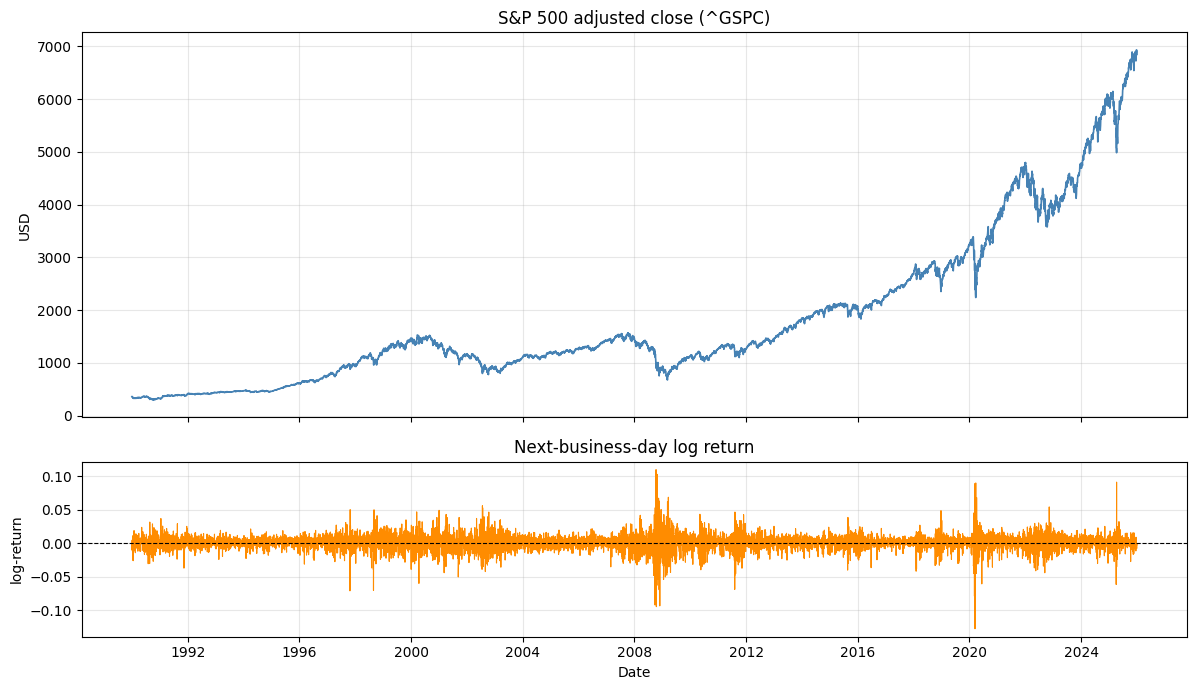

In [13]:
AS_OF = pd.Timestamp("2026-01-02")
df = svc.get_series(SP500_SERIES_ID, as_of=AS_OF).sort_values("timestamp").reset_index(drop=True)
fig, _ = plot_price_and_returns(df)
plt.show()

## 5. Targets + diagnostics

In [14]:
print(summarize_log_returns(df))
target_df = build_next_day_targets(df)
target_df.tail()

n_obs                           9066.000000
mean_log_ret_1b                    0.000325
std_log_ret_1b                     0.011385
min_log_ret_1b                    -0.127652
max_log_ret_1b                     0.109572
pct_negative_log_return_days       0.462608
dtype: float64


,timestamp,close_t,close_t_plus_1b,log_ret_1b
9061,2025-12-23,6909.790039,6932.049805,0.003216
9062,2025-12-24,6932.049805,6929.939941,-0.000304
9063,2025-12-26,6929.939941,6905.740234,-0.003498
9064,2025-12-29,6905.740234,6896.240234,-0.001377
9065,2025-12-30,6896.240234,6845.500000,-0.007385


## 6. Distribution

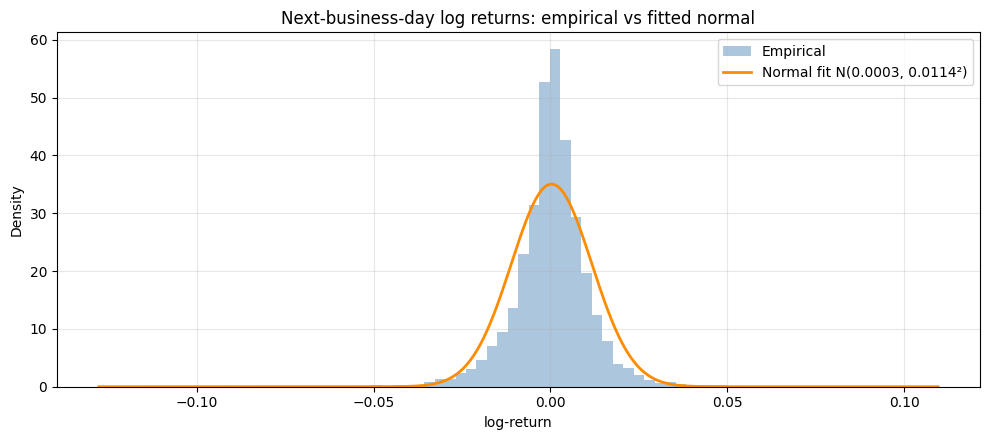

In [15]:
fig, _ = plot_log_return_distribution(df)
plt.show()